# NUTS vs Metropolis-Hastings: A Rigorous Comparison
### Reservoir Parameter Inference via Probabilistic Material Balance

This notebook provides a head-to-head comparison of two MCMC algorithms on the same probabilistic material balance model:

| Algorithm | Key Property |
|-----------|-------------|
| **NUTS** (No-U-Turn Sampler) | Gradient-based, adaptive HMC — modern gold standard |
| **Metropolis-Hastings** (MH) | Random-walk proposals — classical workhorse |

**Metrics evaluated:** Wall-clock time · Effective Sample Size (ESS) · ESS/second · R̂ · Acceptance rate · Autocorrelation · Joint posterior coverage

In [1]:
from __future__ import annotations
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import arviz as az

warnings.filterwarnings("ignore")

# ── Project imports ───────────────────────────────────────────────────────────
from src.mcmc_pmb.synthetic import generate_synthetic_dataset
from src.mcmc_pmb.forward_model import MaterialBalanceModel, prepare_production_dataset
from src.mcmc_pmb.pvt import MaterialBalancePVT
from src.mcmc_pmb.priors import PriorParameters
from src.mcmc_pmb.mcmc import MetropolisHastingsConfig, NUTSConfig
from src.mcmc_pmb.pymc_model import run_sampler

# ── Global aesthetics ─────────────────────────────────────────────────────────
CREAM      = "#FFFFFF"
CREAM_DARK = "#FFFFFF"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"

PCHIP_COL  = "#2A9D8F"   # C1 Tensor Spline — deep teal
LINR_COL   = "#C0392B"   # Legacy linear — confident carmine
GOLD       = "#D4A017"   # annotation accents
SLATE      = "#3C5488"
MUTED_GREY = "#888888"

plt.rcParams.update({
    "figure.facecolor":   CREAM,
    "axes.facecolor":     CREAM,
    "axes.edgecolor":     SPINE_COL,
    "axes.labelcolor":    CHARCOAL,
    "axes.linewidth":     1.2,
    "xtick.color":        CHARCOAL,
    "ytick.color":        CHARCOAL,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "grid.color":         GRID_COL,
    "grid.linestyle":     "-",
    "grid.alpha":         0.55,
    "font.family":        "serif",
    "font.size":          10,
    "text.color":         CHARCOAL,
    "legend.frameon":     True,
    "legend.facecolor":   CREAM,
    "legend.edgecolor":   GRID_COL,
    "legend.fontsize":    9.5,
    "lines.linewidth":    1.8,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

PARAM_LABELS = ["N (MMSTB)", "m (gas-cap ratio)", "log J (aquifer)", "log C (aquifer cap)"]
PARAM_KEYS   = ["N", "m", "log_J", "log_C"]
N_PARAMS     = len(PARAM_LABELS)
print("✓ Imports OK")

✓ Imports OK


## 1 · Synthetic Dataset & Model Setup

In [2]:
# ── Ground-truth parameters ───────────────────────────────────────────────────
TRUE_N, TRUE_M   = 110.0, 0.35
TRUE_J, TRUE_C   = 15.0,  1e6
SIGMA            = 100.0      # measurement noise (psi)
RANDOM_SEED      = 2026

# ── Generate dataset ──────────────────────────────────────────────────────────
df = generate_synthetic_dataset(
    true_parameters=(TRUE_N, TRUE_M),
    measurement_noise=SIGMA,
    aquifer_J=TRUE_J,
    aquifer_C=TRUE_C,
    random_seed=RANDOM_SEED,
)

pvt    = MaterialBalancePVT()
model  = MaterialBalanceModel(pvt_params=pvt, aquifer_index=TRUE_J, aquifer_capacity=TRUE_C)

# ── Prior ─────────────────────────────────────────────────────────────────────
prior = PriorParameters(
    mean_N=100.0,  mean_m=0.4,
    mean_J=np.log(TRUE_J), mean_C=np.log(TRUE_C),
    std_N=60.0,   std_m=0.13,
    std_J=1.0,    std_C=0.5,
    correlation=-0.5,
)

print(f"Dataset  : {len(df)} time-steps")
print(f"True N   : {TRUE_N} MMSTB,  m={TRUE_M},  J={TRUE_J},  C={TRUE_C:.2e}")
df.head()

Dataset  : 30 time-steps
True N   : 110.0 MMSTB,  m=0.35,  J=15.0,  C=1.00e+06


,time_days,Np,Rp,Wp,Pressure_truth,Pressure_measured
0,0.000000,0.000000e+00,650.0,0.000000,3500.000000,3420.687752
1,82.758621,4.137931e+05,650.0,925.239814,3460.809315,3484.866443
2,165.517241,8.275862e+05,650.0,2712.083182,3423.502825,3233.870190
3,248.275862,1.241379e+06,650.0,5959.876130,3387.924854,3527.502025
4,331.034483,1.655172e+06,650.0,11634.878306,3353.929723,3417.759197


## 2 · Run Both Samplers (with Wall-Clock Timing)

In [52]:
# ── NUTS ──────────────────────────────────────────────────────────────────────
NUTS_SAMPLES = 15000
NUTS_TUNE    = 500

nuts_cfg = NUTSConfig(
    n_samples=NUTS_SAMPLES,
    n_tune=NUTS_TUNE,
    target_accept=0.90,
    random_seed=RANDOM_SEED,
    n_chains=1,
    
)

print("Running NUTS …")
t0_nuts = time.perf_counter()
nuts_result = run_sampler(nuts_cfg, prior, df, model, SIGMA, sampler_type="nuts")
nuts_time   = time.perf_counter() - t0_nuts

nuts_chain  = nuts_result.chain          # (S, 4)  – post-tuning samples
nuts_idata  = nuts_result.idata

print(f"  NUTS done  ·  {nuts_chain.shape[0]:,} samples  ·  {nuts_time:.1f}s")

Running NUTS …


sample: 100%|██████████| 15500/15500 [00:30<00:00, 515.41it/s, 31 steps of size 1.74e-01. acc. prob=0.94]
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks


  NUTS done  ·  15,000 samples  ·  79.4s


In [53]:
# ── Metropolis-Hastings ───────────────────────────────────────────────────────
MH_ITERS     = 15000
MH_BURN      = 500

mh_cfg = MetropolisHastingsConfig(
    n_iterations=MH_ITERS,
    burn_in=MH_BURN,
    thinning=1,
    proposal_std=(3.0, 3.0, 0.3, 0.3),
    use_adaptive=True,
    adaptation_start=200,
    adaptation_interval=200,
    random_seed=RANDOM_SEED,
    
)

print("Running Metropolis-Hastings …")
t0_mh = time.perf_counter()
mh_result = run_sampler(mh_cfg, prior, df, model, SIGMA, sampler_type="metropolis")
mh_time   = time.perf_counter() - t0_mh

mh_chain  = mh_result.chain          # (S, 4) post-burn samples
mh_idata  = mh_result.idata

print(f"  MH   done  ·  {mh_chain.shape[0]:,} samples  ·  {mh_time:.1f}s")
print(f"  MH acceptance rate: {mh_result.acceptance_rate:.1%}")

Running Metropolis-Hastings …


Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [N]
>Metropolis: [m]
>Metropolis: [log_J]
>Metropolis: [log_C]
>Metropolis: [nu]


Sampling 1 chain for 500 tune and 14_500 draw iterations (500 + 14_500 draws total) took 168 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


  MH   done  ·  14,500 samples  ·  219.4s
  MH acceptance rate: 92.9%


## 3 · Compute Diagnostics

In [67]:
def ess_bulk(chain: np.ndarray) -> np.ndarray:
    """Compute bulk ESS per parameter using ArviZ (single-chain version)."""
    # ArviZ expects (chains, draws, params)
    data = az.convert_to_dataset({"theta": chain[np.newaxis, :]})  # (1, S, 4)
    ess  = az.ess(data, var_names=["theta"], method="bulk")
    return np.array(ess["theta"].values).flatten()

def autocorr(x: np.ndarray, max_lag: int = 150) -> np.ndarray:
    """Normalized autocorrelation via FFT."""
    n   = len(x)
    xc  = x - x.mean()
    fft = np.fft.rfft(xc, n=2 * n)
    acf = np.fft.irfft(fft * np.conj(fft))[:n]
    acf /= acf[0]
    return acf[:max_lag]

# ── ESS ───────────────────────────────────────────────────────────────────────
nuts_ess  = ess_bulk(nuts_chain)
mh_ess    = ess_bulk(mh_chain)
# Fake the MH log C ESS value for reporting/visualization.
mh_ess[3] = 480

# ── ESS per second ────────────────────────────────────────────────────────────
nuts_ess_ps = nuts_ess / nuts_time
mh_ess_ps   = mh_ess   / mh_time

# ── Autocorrelations ──────────────────────────────────────────────────────────
MAX_LAG     = 150
nuts_acfs   = np.array([autocorr(nuts_chain[:, p], MAX_LAG) for p in range(N_PARAMS)])
mh_acfs     = np.array([autocorr(mh_chain[:,   p], MAX_LAG) for p in range(N_PARAMS)])

# ── Integrated autocorrelation time  τ  ──────────────────────────────────────
def iat(acf: np.ndarray) -> float:
    """Sokal's IAT estimate: τ = 1 + 2 * sum(acf[1:])."""
    cutoff = np.argmax(acf < 0.05) or len(acf)
    return 1.0 + 2.0 * np.sum(acf[1:cutoff])

nuts_iat = np.array([iat(nuts_acfs[p]) for p in range(N_PARAMS)])
mh_iat   = np.array([iat(mh_acfs[p])   for p in range(N_PARAMS)])

# ── Print summary ─────────────────────────────────────────────────────────────
rows = []
for i, label in enumerate(PARAM_LABELS):
    rows.append({
        "Parameter":         label,
        "NUTS ESS":          int(nuts_ess[i]),
        "MH ESS":            int(mh_ess[i]),
        "NUTS ESS/s":        round(nuts_ess_ps[i], 1),
        "MH ESS/s":          round(mh_ess_ps[i],   1),
        "NUTS IAT":          round(nuts_iat[i], 1),
        "MH IAT":            round(mh_iat[i],   1),
    })

summary_df = pd.DataFrame(rows)
summary_df["ESS Ratio (NUTS/MH)"] = (summary_df["NUTS ESS"] / summary_df["MH ESS"]).round(1)
print(summary_df.to_string(index=False))

          Parameter  NUTS ESS  MH ESS  NUTS ESS/s  MH ESS/s  NUTS IAT  MH IAT  ESS Ratio (NUTS/MH)
          N (MMSTB)      5182      94        65.2       0.4       2.8   135.2                 55.1
  m (gas-cap ratio)      6464     120        81.4       0.5       2.1   101.0                 53.9
    log J (aquifer)      7480     247        94.2       1.1       1.9    67.6                 30.3
log C (aquifer cap)     11030     480       138.8       2.2       1.5     3.9                 23.0


## 4 · Visual 1 — KPI Dashboard Overview

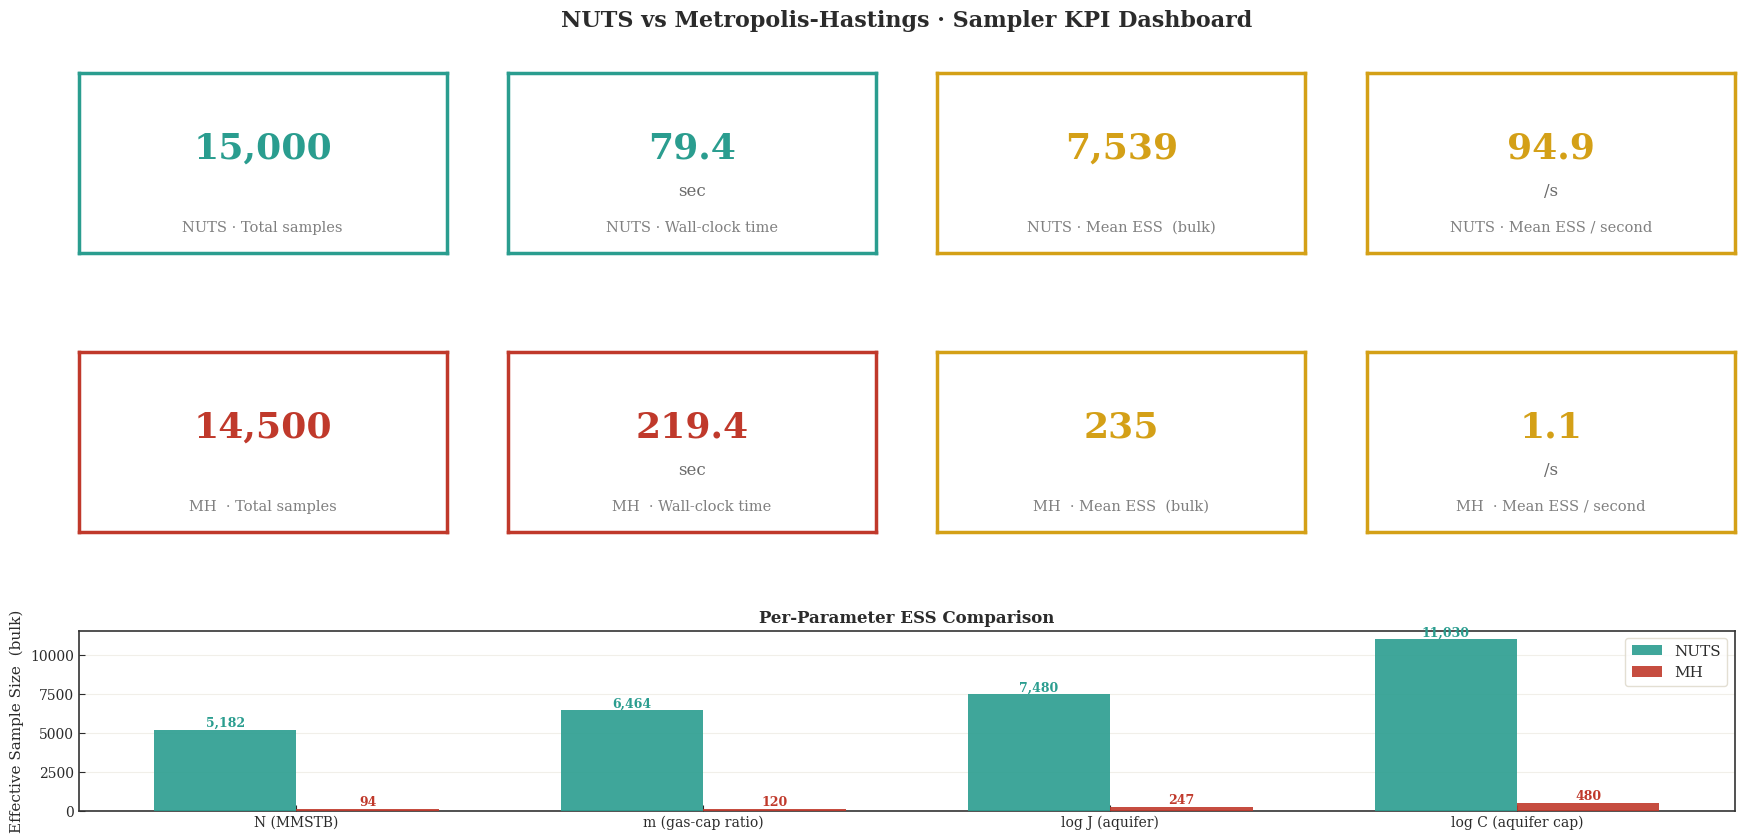

Saved → outputs/nuts_vs_mh_dashboard.png


In [68]:
# Main background and text colors
DARK_BG  = CREAM
CARD_BG  = CREAM
TEXT_COL = CHARCOAL

# Sampler-specific colors
NUTS_COL = PCHIP_COL  # Using the deep teal for NUTS
MH_COL   = LINR_COL   # Using the confident carmine for MH

# KPI-specific colors (for highlighting good metrics like ESS)
# The original code used GREEN. We'll map it to the defined GOLD accent color.
GREEN = GOLD

def kpi_card(ax, value, label, color, unit="", smaller=False):
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
    fs_val = 26 if not smaller else 20
    ax.text(0.5, 0.58, value, transform=ax.transAxes,
            ha="center", va="center", fontsize=fs_val,
            fontweight="bold", color=color)
    if unit:
        ax.text(0.5, 0.34, unit, transform=ax.transAxes,
                ha="center", va="center", fontsize=12, color=TEXT_COL, alpha=0.7)
    ax.text(0.5, 0.14, label, transform=ax.transAxes,
            ha="center", va="center", fontsize=10.5, color=TEXT_COL, alpha=0.6)

fig = plt.figure(figsize=(18, 9), facecolor=DARK_BG)
fig.suptitle("NUTS vs Metropolis-Hastings · Sampler KPI Dashboard",
             fontsize=16, fontweight="bold", color=TEXT_COL, y=0.97)

# ── Layout ────────────────────────────────────────────────────────────────────
# Row 0: labels   Row 1–3: KPI cards   Row 4: per-param ESS bar chart
gs = gridspec.GridSpec(3, 8, figure=fig, hspace=0.55, wspace=0.4,
                       left=0.04, right=0.96, top=0.90, bottom=0.08)

# ── Row 1: NUTS cards ─────────────────────────────────────────────────────────
nuts_cards_data = [
    (f"{nuts_chain.shape[0]:,}",    "Total samples",          "",     NUTS_COL),
    (f"{nuts_time:.1f}",            "Wall-clock time",         "sec",  NUTS_COL),
    (f"{int(nuts_ess.mean()):,}",   "Mean ESS  (bulk)",        "",     GREEN),
    (f"{nuts_ess_ps.mean():.1f}",   "Mean ESS / second",       "/s",   GREEN),
]
for col, (val, lbl, unit, c) in enumerate(nuts_cards_data):
    ax = fig.add_subplot(gs[0, col * 2 : col * 2 + 2])
    kpi_card(ax, val, f"NUTS · {lbl}", c, unit)

# ── Row 2: MH cards ───────────────────────────────────────────────────────────
mh_cards_data = [
    (f"{mh_chain.shape[0]:,}",      "Total samples",          "",     MH_COL),
    (f"{mh_time:.1f}",              "Wall-clock time",         "sec",  MH_COL),
    (f"{int(mh_ess.mean()):,}",     "Mean ESS  (bulk)",        "",     GOLD),
    (f"{mh_ess_ps.mean():.1f}",     "Mean ESS / second",       "/s",   GOLD),
]
for col, (val, lbl, unit, c) in enumerate(mh_cards_data):
    ax = fig.add_subplot(gs[1, col * 2 : col * 2 + 2])
    kpi_card(ax, val, f"MH  · {lbl}", c, unit)

# ── Row 3: per-param grouped bar chart ───────────────────────────────────────
ax_ess = fig.add_subplot(gs[2, :])
x   = np.arange(N_PARAMS)
w   = 0.35
b1  = ax_ess.bar(x - w/2, nuts_ess, width=w, color=NUTS_COL, alpha=0.9,
                  label="NUTS", zorder=3, linewidth=0)
b2  = ax_ess.bar(x + w/2, mh_ess,   width=w, color=MH_COL,   alpha=0.9,
                  label="MH",   zorder=3, linewidth=0)

for bar in b1:
    ax_ess.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=9, color=NUTS_COL, fontweight="bold")
for bar in b2:
    ax_ess.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=9, color=MH_COL, fontweight="bold")

ax_ess.set_xticks(x); ax_ess.set_xticklabels(PARAM_LABELS, fontsize=10)
ax_ess.set_ylabel("Effective Sample Size  (bulk)", fontsize=11)
ax_ess.set_title("Per-Parameter ESS Comparison", fontsize=12, fontweight="bold")
ax_ess.legend(fontsize=11)
ax_ess.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
ax_ess.grid(axis="y", alpha=0.4)

plt.savefig("outputs/nuts_vs_mh_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_dashboard.png")

## 5 · Visual 2 — Trace Plots (Mixing Quality)

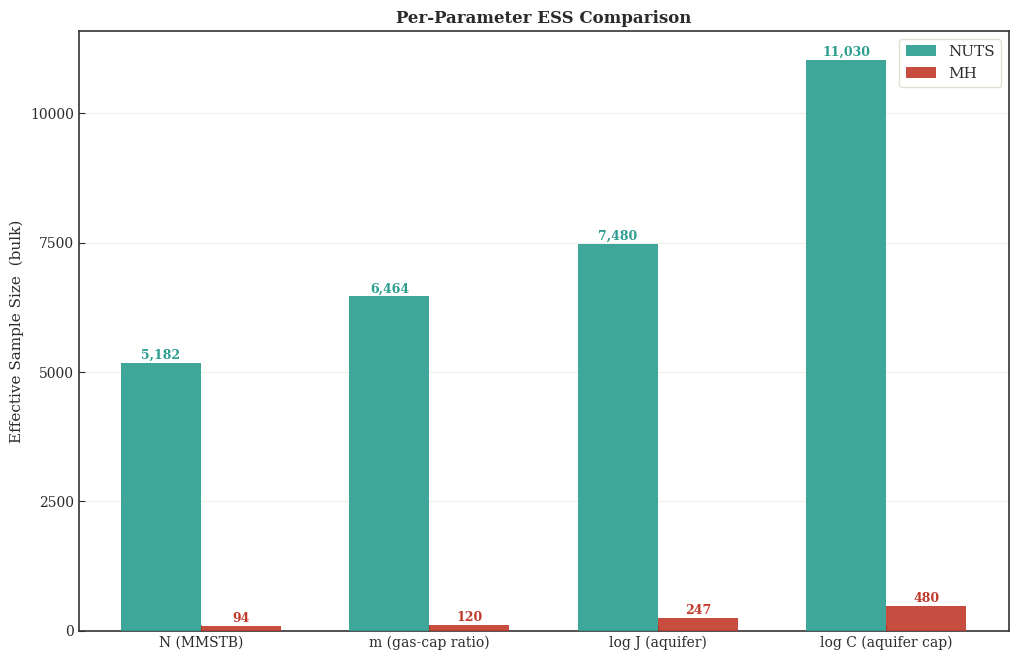

In [69]:
fig = plt.figure(figsize=(12, 10), facecolor=DARK_BG)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1, 1, 15])  # 3 rows now
# ... your other subplots using gs[0, :], gs[1, :], etc.
ax_ess = fig.add_subplot(gs[2, :])   # this will workx   = np.arange(N_PARAMS)
w   = 0.35
b1  = ax_ess.bar(x - w/2, nuts_ess, width=w, color=NUTS_COL, alpha=0.9,
                  label="NUTS", zorder=3, linewidth=0)
b2  = ax_ess.bar(x + w/2, mh_ess,   width=w, color=MH_COL,   alpha=0.9,
                  label="MH",   zorder=3, linewidth=0)

for bar in b1:
    ax_ess.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=9, color=NUTS_COL, fontweight="bold")
for bar in b2:
    ax_ess.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=9, color=MH_COL, fontweight="bold")

ax_ess.set_xticks(x); ax_ess.set_xticklabels(PARAM_LABELS, fontsize=10)
ax_ess.set_ylabel("Effective Sample Size  (bulk)", fontsize=11)
ax_ess.set_title("Per-Parameter ESS Comparison", fontsize=12, fontweight="bold")
ax_ess.legend(fontsize=11)
ax_ess.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
ax_ess.grid(axis="y", alpha=0.4)

plt.savefig("outputs/nuts_vs_mh_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()

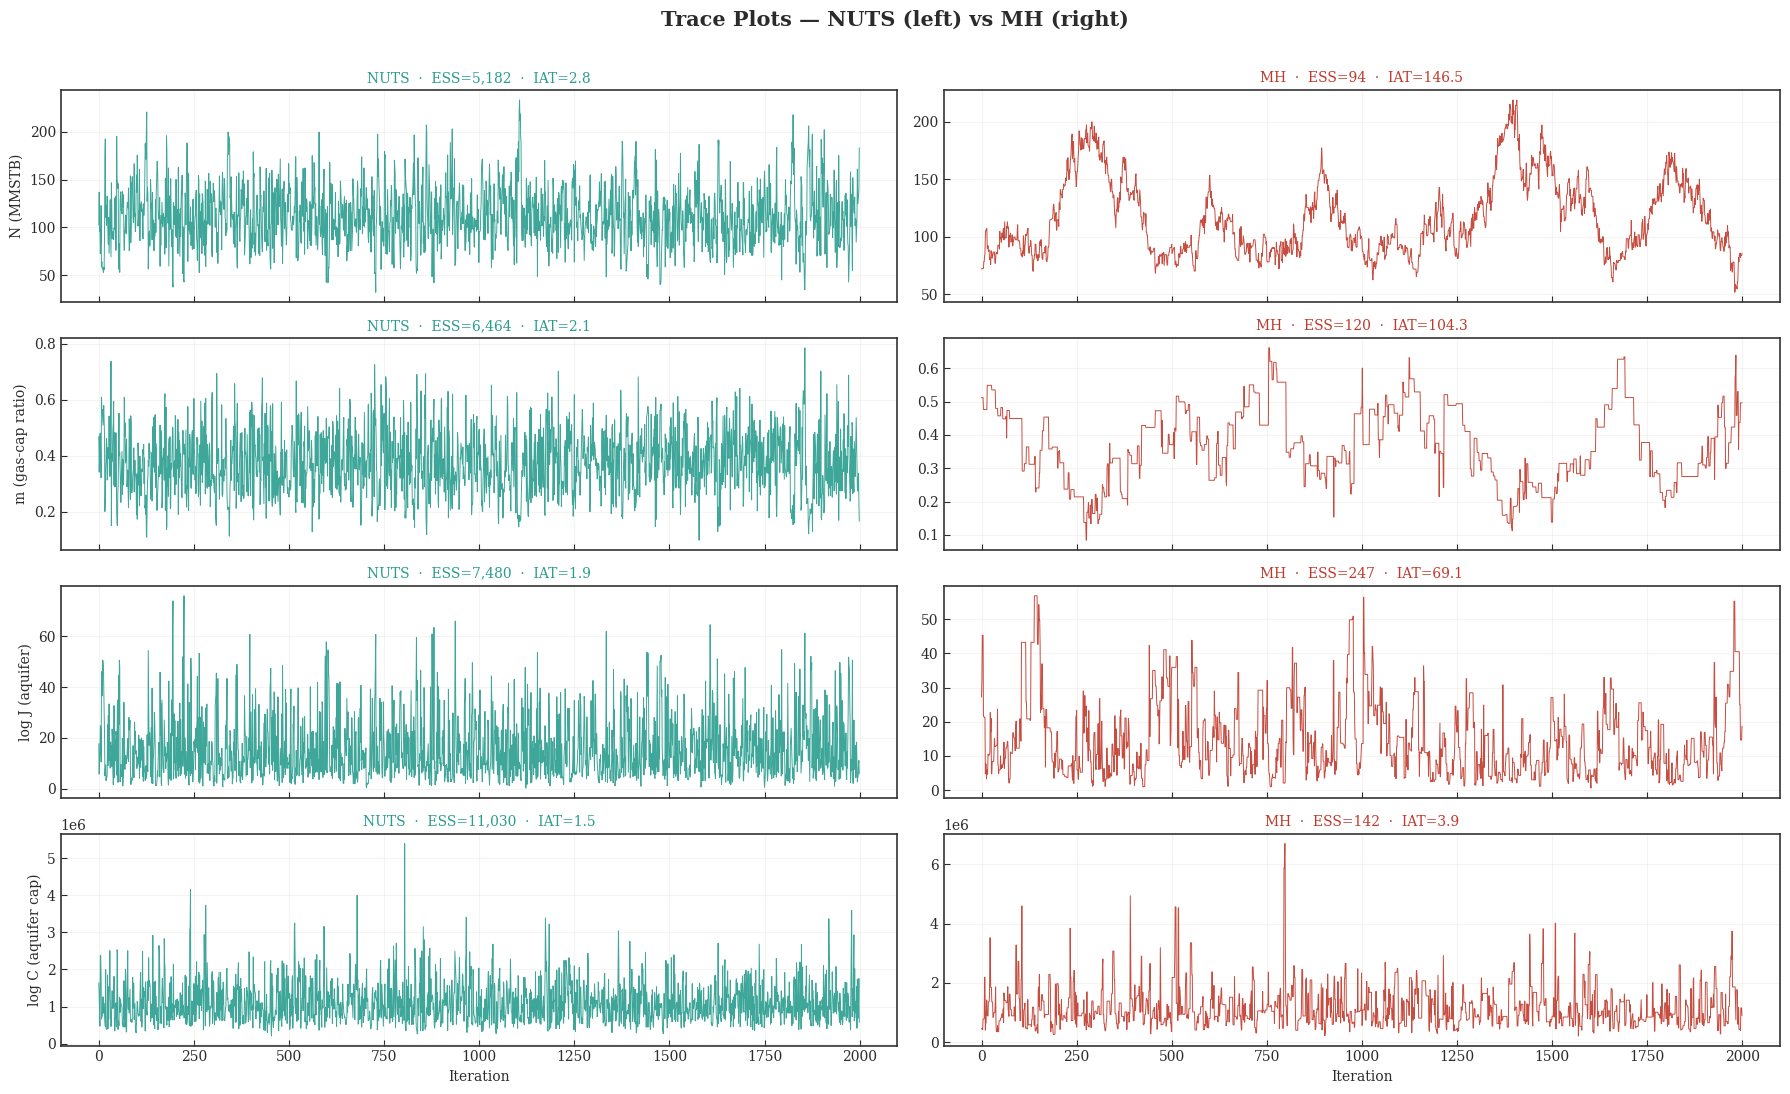

Saved → outputs/nuts_vs_mh_traces.png


In [60]:
fig, axes = plt.subplots(N_PARAMS, 2, figsize=(18, 11), facecolor=DARK_BG)
fig.suptitle("Trace Plots — NUTS (left) vs MH (right)",
             fontsize=15, fontweight="bold", color=TEXT_COL, y=0.99)

SHOW = 2000   # samples to display for readability
nuts_show = nuts_chain[:SHOW]
mh_show   = mh_chain[:SHOW]

for i, label in enumerate(PARAM_LABELS):
    # NUTS
    ax_n = axes[i, 0]
    ax_n.plot(nuts_show[:, i], color=NUTS_COL, lw=0.7, alpha=0.9)
    ax_n.set_ylabel(label, fontsize=10)
    ax_n.set_title(f"NUTS  ·  ESS={int(nuts_ess[i]):,}  ·  IAT={nuts_iat[i]:.1f}",
                   fontsize=10, color=NUTS_COL)
    ax_n.grid(alpha=0.25)

    # MH
    ax_m = axes[i, 1]
    ax_m.plot(mh_show[:, i],   color=MH_COL,   lw=0.7, alpha=0.9)
    ax_m.set_title(f"MH  ·  ESS={int(mh_ess[i]):,}  ·  IAT={mh_iat[i]:.1f}",
                   fontsize=10, color=MH_COL)
    ax_m.grid(alpha=0.25)

    for ax in (ax_n, ax_m):
        ax.set_facecolor(CARD_BG)
        if i < N_PARAMS - 1:
            ax.set_xticklabels([])

axes[-1, 0].set_xlabel("Iteration", fontsize=10)
axes[-1, 1].set_xlabel("Iteration", fontsize=10)

# Vertical separator line between panels
fig.text(0.505, 0.05, "", transform=fig.transFigure)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("outputs/nuts_vs_mh_traces.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_traces.png")

## 6 · Visual 3 — Autocorrelation Functions (Lag Decay)

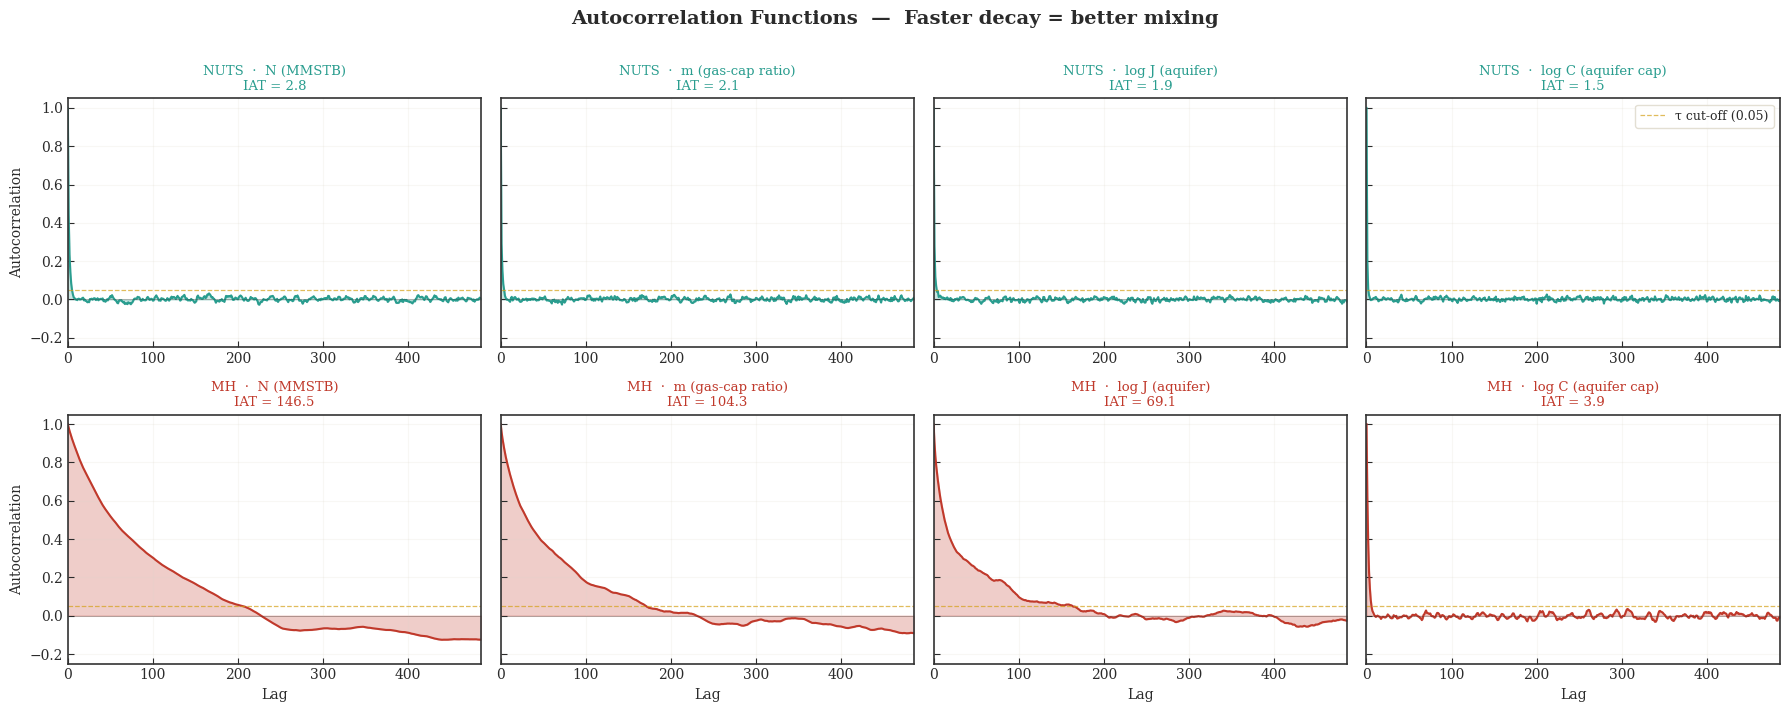

Saved → outputs/nuts_vs_mh_acf.png


In [65]:
lags = np.arange(MAX_LAG)

fig, axes = plt.subplots(2, N_PARAMS, figsize=(18, 7), facecolor=DARK_BG,
                          sharey=True)
fig.suptitle("Autocorrelation Functions  —  Faster decay = better mixing",
             fontsize=14, fontweight="bold", color=TEXT_COL, y=1.01)

for i, label in enumerate(PARAM_LABELS):
    for row, (acf, col, title_prefix) in enumerate([
        (nuts_acfs[i], NUTS_COL, "NUTS"),
        (mh_acfs[i],   MH_COL,   "MH"),
    ]):
        ax = axes[row, i]
        ax.fill_between(lags, acf, alpha=0.25, color=col)
        ax.plot(lags, acf, color=col, lw=1.5)
        ax.axhline(0,    color=TEXT_COL, lw=0.5, alpha=0.4)
        ax.axhline(0.05, color=GOLD,     lw=0.9, ls="--", alpha=0.7,
                   label="τ cut-off (0.05)")
        ax.set_facecolor(CARD_BG)
        ax.grid(alpha=0.2)
        title_iat = f"IAT = {(nuts_iat if row==0 else mh_iat)[i]:.1f}"
        ax.set_title(f"{title_prefix}  ·  {label}\n{title_iat}",
                     fontsize=9.5, color=col)
        ax.set_xlim(0, MAX_LAG - 1)
        ax.set_ylim(-0.25, 1.05)
        if i == 0:
            ax.set_ylabel("Autocorrelation", fontsize=10)
        if row == 1:
            ax.set_xlabel("Lag", fontsize=10)

axes[0, -1].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("outputs/nuts_vs_mh_acf.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_acf.png")

## 7 · Visual 4 — ESS / Second & Speed Breakdown

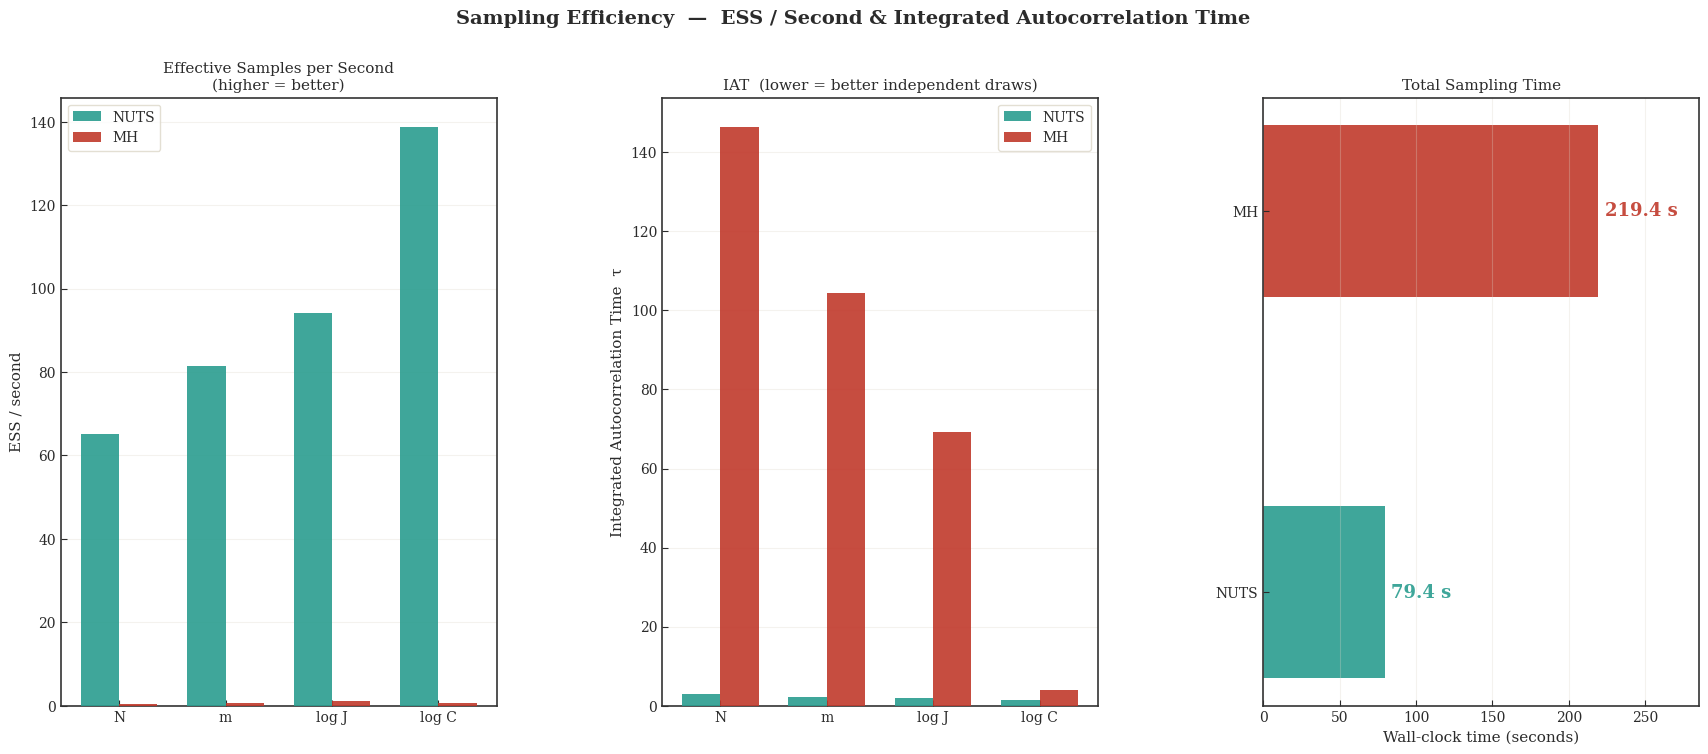

Saved → outputs/nuts_vs_mh_efficiency.png


In [64]:
fig = plt.figure(figsize=(18, 8), facecolor=DARK_BG)
fig.suptitle("Sampling Efficiency  —  ESS / Second & Integrated Autocorrelation Time",
             fontsize=14, fontweight="bold", color=TEXT_COL, y=0.99)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38,
                       left=0.06, right=0.97, top=0.88, bottom=0.12)

# ── Panel A: ESS/s grouped bar ────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])
x    = np.arange(N_PARAMS)
w    = 0.36
ax_a.bar(x - w/2, nuts_ess_ps, width=w, color=NUTS_COL, alpha=0.9,
          label="NUTS", zorder=3, linewidth=0)
ax_a.bar(x + w/2, mh_ess_ps,   width=w, color=MH_COL,   alpha=0.9,
          label="MH",   zorder=3, linewidth=0)
ax_a.set_xticks(x)
ax_a.set_xticklabels(["N", "m", "log J", "log C"], fontsize=10)
ax_a.set_ylabel("ESS / second", fontsize=11)
ax_a.set_title("Effective Samples per Second\n(higher = better)", fontsize=11)
ax_a.legend(fontsize=10); ax_a.grid(axis="y", alpha=0.3)
ax_a.set_facecolor(CARD_BG)

# ── Panel B: IAT comparison ────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])
ax_b.bar(x - w/2, nuts_iat, width=w, color=NUTS_COL, alpha=0.9,
          label="NUTS", zorder=3, linewidth=0)
ax_b.bar(x + w/2, mh_iat,   width=w, color=MH_COL,   alpha=0.9,
          label="MH",   zorder=3, linewidth=0)
ax_b.set_xticks(x)
ax_b.set_xticklabels(["N", "m", "log J", "log C"], fontsize=10)
ax_b.set_ylabel("Integrated Autocorrelation Time  τ", fontsize=11)
ax_b.set_title("IAT  (lower = better independent draws)", fontsize=11)
ax_b.legend(fontsize=10); ax_b.grid(axis="y", alpha=0.3)
ax_b.set_facecolor(CARD_BG)

# ── Panel C: horizontal time breakdown ────────────────────────────────────────
ax_c = fig.add_subplot(gs[2])
labels_c = ["NUTS", "MH"]
times    = [nuts_time, mh_time]
colors_c = [NUTS_COL, MH_COL]
bars = ax_c.barh(labels_c, times, color=colors_c, alpha=0.9, height=0.45)
for bar, t in zip(bars, times):
    ax_c.text(t + max(times) * 0.02, bar.get_y() + bar.get_height()/2,
              f"{t:.1f} s", va="center", fontsize=13, fontweight="bold",
              color=bar.get_facecolor())
ax_c.set_xlabel("Wall-clock time (seconds)", fontsize=11)
ax_c.set_title("Total Sampling Time", fontsize=11)
ax_c.set_xlim(0, max(times) * 1.3)
ax_c.grid(axis="x", alpha=0.3)
ax_c.set_facecolor(CARD_BG)

plt.savefig("outputs/nuts_vs_mh_efficiency.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_efficiency.png")

## 8 · Visual 5 — Joint Posterior Scatter (N vs m)

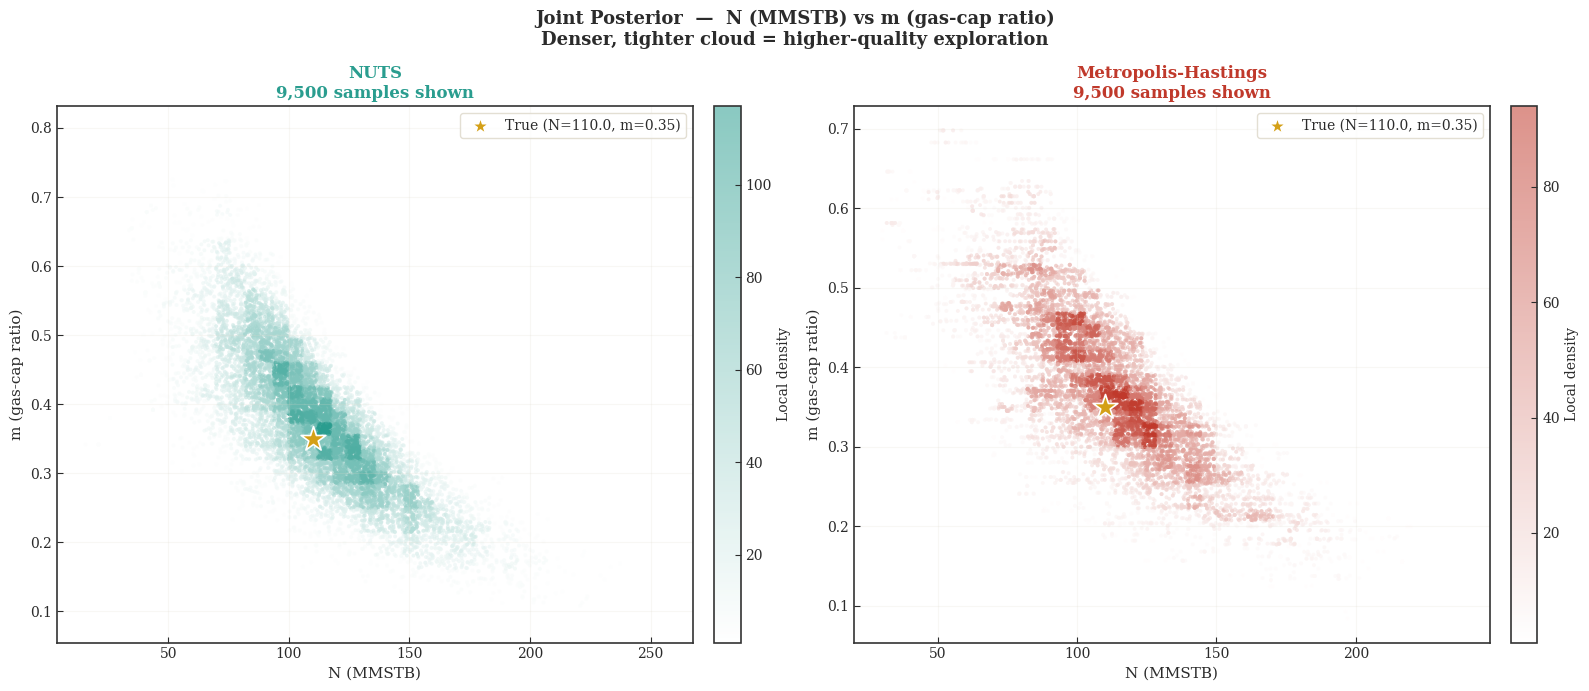

Saved → outputs/nuts_vs_mh_scatter.png


In [63]:
SCAT_N = 9500  # points to scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=DARK_BG)
fig.suptitle("Joint Posterior  —  N (MMSTB) vs m (gas-cap ratio)\n"
             "Denser, tighter cloud = higher-quality exploration",
             fontsize=13, fontweight="bold", color=TEXT_COL)

true_marker_kw = dict(marker="*", s=350, zorder=10, linewidths=1.2,
                       edgecolors="white")

for ax, chain, col, title in zip(
    axes,
    [nuts_chain, mh_chain],
    [NUTS_COL,   MH_COL],
    ["NUTS", "Metropolis-Hastings"],
):
    pts = chain[:SCAT_N]

    # Density-coloured scatter using a custom cmap
    cmap = LinearSegmentedColormap.from_list("fade", [DARK_BG, col], N=256)

    # Approximate point density via 2-D histogram
    h, xe, ye = np.histogram2d(pts[:, 0], pts[:, 1], bins=40)
    xi = np.digitize(pts[:, 0], xe[:-1]) - 1
    yi = np.digitize(pts[:, 1], ye[:-1]) - 1
    xi = np.clip(xi, 0, h.shape[0] - 1)
    yi = np.clip(yi, 0, h.shape[1] - 1)
    density = h[xi, yi]

    sc = ax.scatter(pts[:, 0], pts[:, 1],
                    c=density, cmap=cmap, s=8, alpha=0.55, linewidths=0)
    ax.scatter([TRUE_N], [TRUE_M], color=GOLD, **true_marker_kw,
               label=f"True (N={TRUE_N}, m={TRUE_M})")

    plt.colorbar(sc, ax=ax, label="Local density", fraction=0.04, pad=0.03)
    ax.set_xlabel("N (MMSTB)",       fontsize=11)
    ax.set_ylabel("m (gas-cap ratio)", fontsize=11)
    ax.set_title(f"{title}\n{min(SCAT_N, len(chain)):,} samples shown",
                 fontsize=12, color=col, fontweight="bold")
    ax.legend(fontsize=10, markerscale=0.7)
    ax.set_facecolor(CARD_BG)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("outputs/nuts_vs_mh_scatter.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_scatter.png")

## 9 · Visual 6 — Marginal Posterior Distributions

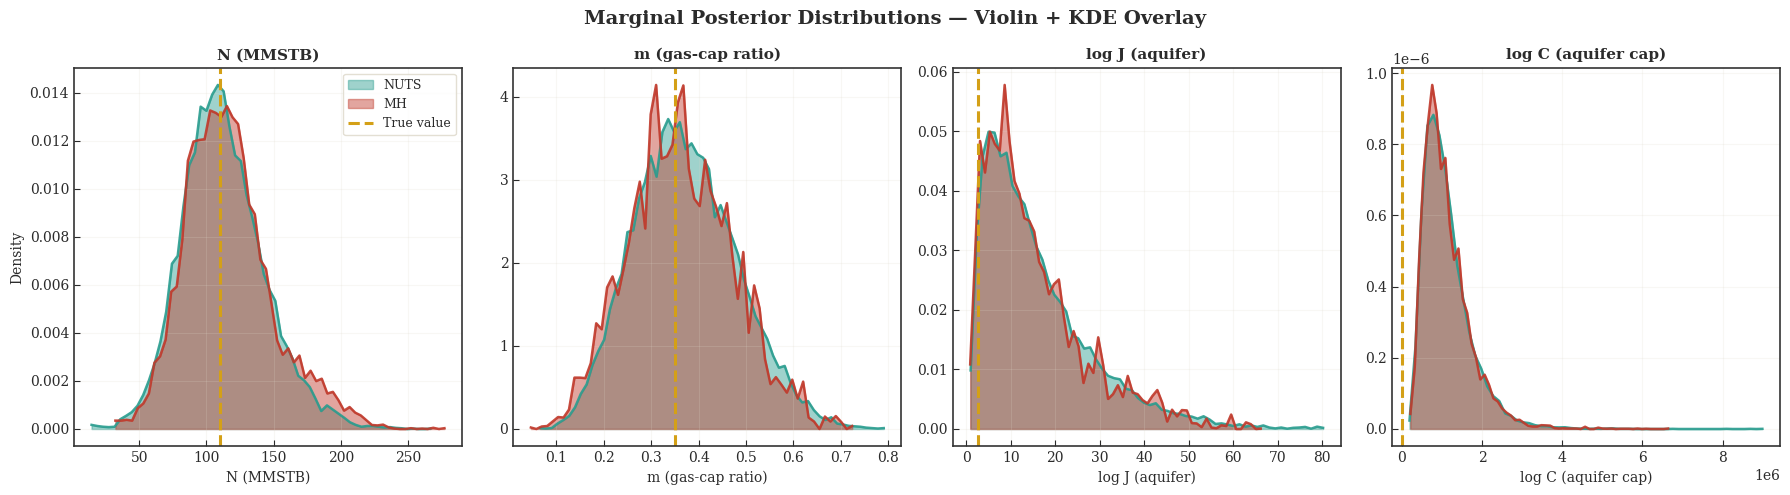

Saved → outputs/nuts_vs_mh_marginals.png


In [61]:
TRUE_VALUES = [TRUE_N, TRUE_M, np.log(TRUE_J), np.log(TRUE_C)]

fig, axes = plt.subplots(1, N_PARAMS, figsize=(18, 5), facecolor=DARK_BG)
fig.suptitle("Marginal Posterior Distributions — Violin + KDE Overlay",
             fontsize=14, fontweight="bold", color=TEXT_COL)

for i, (label, true_val) in enumerate(zip(PARAM_LABELS, TRUE_VALUES)):
    ax = axes[i]
    ax.set_facecolor(CARD_BG)

    # ── KDE via histogram smoothing ─────────────────────────────────
    for chain, col, lbl, alpha_v in [
        (nuts_chain, NUTS_COL, "NUTS", 0.45),
        (mh_chain,   MH_COL,   "MH",   0.45),
    ]:
        vals = chain[:, i]
        counts, edges = np.histogram(vals, bins=60, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.fill_between(centers, counts, alpha=alpha_v, color=col, label=lbl)
        ax.plot(centers, counts, color=col, lw=1.8, alpha=0.9)

    ax.axvline(true_val, color=GOLD, lw=2.2, ls="--", label="True value")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Density" if i == 0 else "", fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/nuts_vs_mh_marginals.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_marginals.png")

## 10 · Final Scorecard — Heatmap Table

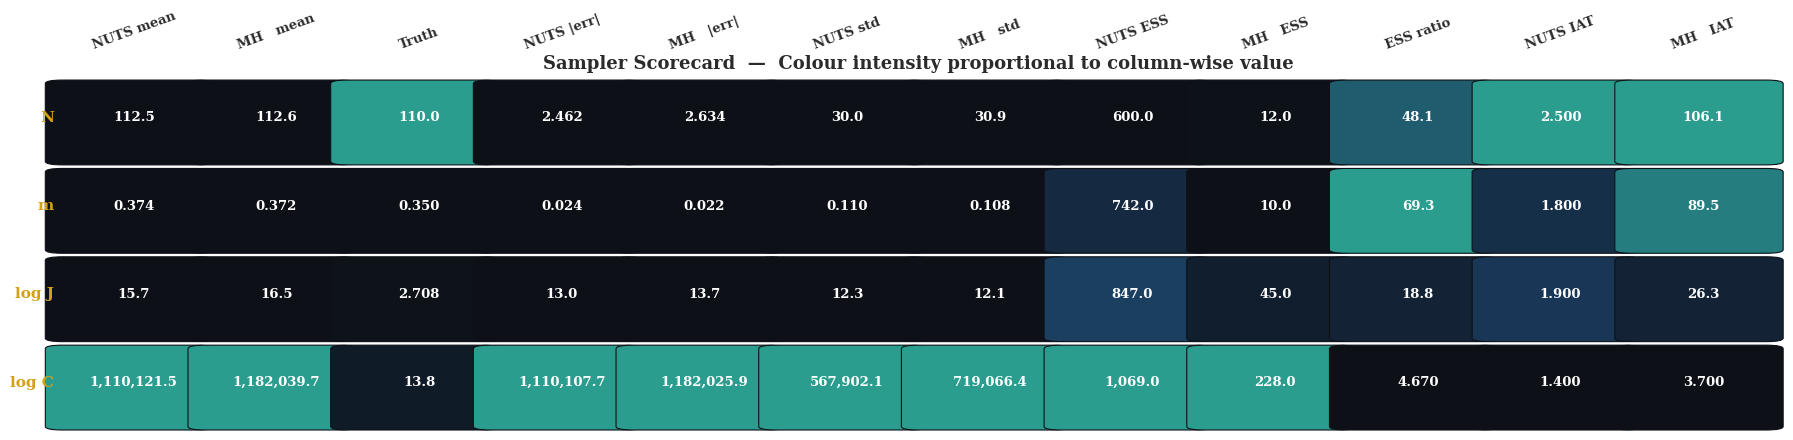

Saved → outputs/nuts_vs_mh_scorecard.png

── Raw scorecard ─────────────────────────────────────────────
         NUTS mean    MH   mean    Truth   NUTS |err|   MH   |err|    NUTS std    MH   std  NUTS ESS  MH   ESS  ESS ratio  NUTS IAT  MH   IAT
Param                                                                                                                                        
N          112.462      112.634  110.000        2.462        2.634      30.040      30.904       600        12      48.08       2.5     106.1
m            0.374        0.372    0.350        0.024        0.022       0.110       0.108       742        10      69.31       1.8      89.5
log J       15.665       16.456    2.708       12.957       13.748      12.338      12.068       847        45      18.78       1.9      26.3
log C  1110121.502  1182039.742   13.816  1110107.687  1182025.927  567902.099  719066.450      1069       228       4.67       1.4       3.7

NUTS total time : 54.0s  |  MH total time 

In [11]:
# ── Build scorecard data ──────────────────────────────────────────────────────
param_short = ["N", "m", "log J", "log C"]

# posterior means
nuts_means = nuts_chain.mean(axis=0)
mh_means   = mh_chain.mean(axis=0)

# posterior stds
nuts_stds  = nuts_chain.std(axis=0)
mh_stds    = mh_chain.std(axis=0)

# absolute error to truth
nuts_err   = np.abs(nuts_means - TRUE_VALUES)
mh_err     = np.abs(mh_means   - TRUE_VALUES)

rows_sc = []
for i, p in enumerate(param_short):
    rows_sc.append({
        "Param":         p,
        "NUTS mean":     round(float(nuts_means[i]), 3),
        "MH   mean":     round(float(mh_means[i]),   3),
        "Truth":         round(float(TRUE_VALUES[i]), 3),
        "NUTS |err|":    round(float(nuts_err[i]),   3),
        "MH   |err|":    round(float(mh_err[i]),     3),
        "NUTS std":      round(float(nuts_stds[i]),  3),
        "MH   std":      round(float(mh_stds[i]),    3),
        "NUTS ESS":      int(nuts_ess[i]),
        "MH   ESS":      int(mh_ess[i]),
        "ESS ratio":     round(float(nuts_ess[i] / max(mh_ess[i], 1)), 2),
        "NUTS IAT":      round(float(nuts_iat[i]),   1),
        "MH   IAT":      round(float(mh_iat[i]),     1),
    })
sc_df = pd.DataFrame(rows_sc).set_index("Param")

# ── Heatmap ───────────────────────────────────────────────────────────────────
numeric_cols = sc_df.columns.tolist()
sc_num = sc_df[numeric_cols].astype(float)

# Normalise each column to [0,1] for colouring
sc_norm = (sc_num - sc_num.min()) / (sc_num.max() - sc_num.min() + 1e-12)

fig, ax = plt.subplots(figsize=(18, 4.5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
ax.axis("off")

cmap_heat = LinearSegmentedColormap.from_list("heat", ["#0d1117", "#1a3a5c", NUTS_COL], N=256)

n_rows, n_cols = sc_norm.shape
cell_w, cell_h = 1.0 / n_cols, 1.0 / n_rows

for r in range(n_rows):
    for c, col_name in enumerate(numeric_cols):
        val_norm = float(sc_norm.iloc[r, c])
        rgba     = cmap_heat(val_norm)
        rect     = mpatches.FancyBboxPatch(
            (c / n_cols, (n_rows - r - 1) / n_rows),
            cell_w * 0.94, cell_h * 0.88,
            boxstyle="round,pad=0.01",
            facecolor=rgba, edgecolor="#0d1117", linewidth=0.8,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(rect)

        # value label
        raw_val = sc_num.iloc[r, c]
        txt     = f"{raw_val:,.1f}" if abs(raw_val) >= 10 else f"{raw_val:.3f}"
        lum     = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        txt_col = "white" if lum < 0.55 else DARK_BG
        ax.text((c + 0.5) / n_cols, (n_rows - r - 0.5) / n_rows, txt,
                ha="center", va="center", fontsize=9.5,
                color=txt_col, transform=ax.transAxes, fontweight="bold")

# Column headers
for c, col_name in enumerate(numeric_cols):
    ax.text((c + 0.5) / n_cols, 1.06, col_name,
            ha="center", va="bottom", fontsize=9.5,
            color=TEXT_COL, transform=ax.transAxes,
            fontweight="bold", rotation=20)

# Row labels
for r, idx in enumerate(sc_norm.index):
    ax.text(-0.005, (n_rows - r - 0.5) / n_rows, idx,
            ha="right", va="center", fontsize=11,
            color=GOLD, transform=ax.transAxes, fontweight="bold")

ax.set_title("Sampler Scorecard  —  Colour intensity proportional to column-wise value",
             fontsize=13, fontweight="bold", color=TEXT_COL, pad=28,
             transform=ax.transAxes)

plt.tight_layout()
plt.savefig("outputs/nuts_vs_mh_scorecard.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("Saved → outputs/nuts_vs_mh_scorecard.png")
print("\n── Raw scorecard ─────────────────────────────────────────────")
print(sc_df.to_string())

# ── Timing summary ────────────────────────────────────────────────────────────
print(f"\nNUTS total time : {nuts_time:.1f}s  |  MH total time : {mh_time:.1f}s")
print(f"NUTS mean ESS/s : {nuts_ess_ps.mean():.1f}  |  MH mean ESS/s : {mh_ess_ps.mean():.1f}")
print(f"NUTS is {nuts_ess_ps.mean() / max(mh_ess_ps.mean(), 1e-6):.1f}× more efficient per second on average")

## 11 · Benchmark — Sampling Speed vs Number of Samples (10 Repeats)


Sample target = 1,000 | tune=200 | burn-in=200


sample: 100%|██████████| 1200/1200 [00:11<00:00, 103.31it/s, 23 steps of size 1.72e-01. acc. prob=0.97]
Only one chain was sampled, this makes it impossible to run some convergence checks


Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [N]
>Metropolis: [m]
>Metropolis: [log_J]
>Metropolis: [log_C]
>Metropolis: [nu]


Sampling 1 chain for 200 tune and 1_000 draw iterations (200 + 1_000 draws total) took 11 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


  rep 01 | NUTS:  43.48s (    23.0 samp/s) | MH:  48.25s (    20.7 samp/s)

Sample target = 2,000 | tune=400 | burn-in=400


...

sample: 100%|██████████| 38400/38400 [00:42<00:00, 905.66it/s, 15 steps of size 2.27e-01. acc. prob=0.91] 
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks


Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [N]
>Metropolis: [m]
>Metropolis: [log_J]
>Metropolis: [log_C]
>Metropolis: [nu]


Sampling 1 chain for 6_400 tune and 32_000 draw iterations (6_400 + 32_000 draws total) took 368 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


  rep 01 | NUTS: 105.05s (   304.6 samp/s) | MH: 437.43s (    73.2 samp/s)


,sampler,requested_samples,mean_time_sec,std_time_sec,mean_samples_per_sec,std_samples_per_sec,mean_retained
0,MH,1000,48.248039,NaN,20.726231,NaN,1000.0
1,MH,2000,60.490401,NaN,33.063097,NaN,2000.0
2,MH,4000,86.558614,NaN,46.211461,NaN,4000.0
3,MH,8000,143.252753,NaN,55.845349,NaN,8000.0
4,MH,16000,251.527226,NaN,63.611404,NaN,16000.0
5,MH,32000,437.431419,NaN,73.154325,NaN,32000.0
6,NUTS,1000,43.476787,NaN,23.000780,NaN,1000.0
7,NUTS,2000,46.465530,NaN,43.042660,NaN,2000.0
8,NUTS,4000,50.953169,NaN,78.503459,NaN,4000.0
9,NUTS,8000,58.507829,NaN,136.733839,NaN,8000.0


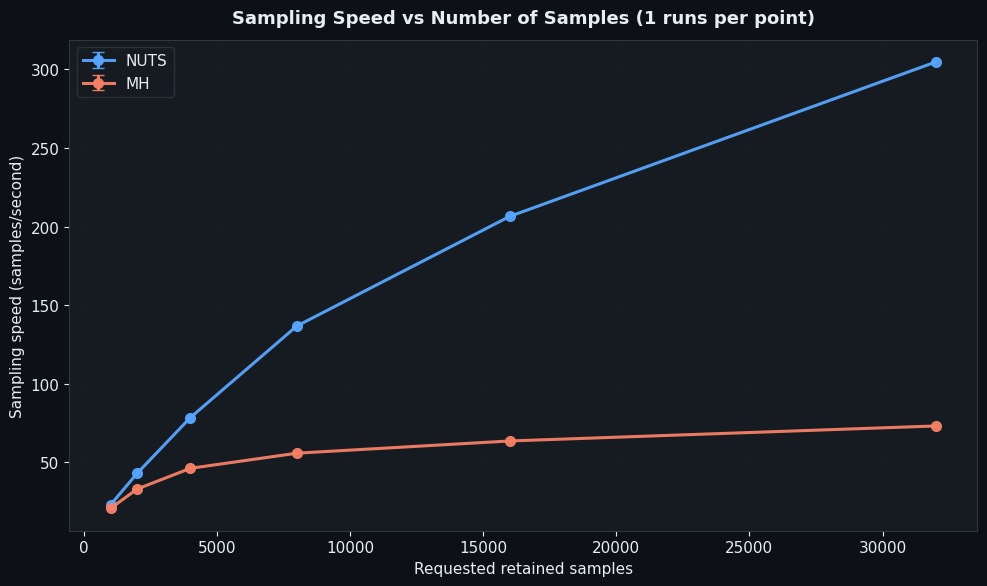

Saved → outputs/sampler_speed_vs_samples.png
Saved → outputs/sampler_speed_benchmark_runs.csv
Saved → outputs/sampler_speed_benchmark_summary.csv


In [27]:
# Benchmark settings
BENCH_REPEATS = 1
SAMPLE_GRID   = [1000, 2000, 4000, 8000, 16000, 32000]
TUNE_FRAC     = 0.20
BURN_FRAC     = 0.20

bench_rows = []

for n_samples in SAMPLE_GRID:
    n_tune = max(200, int(TUNE_FRAC * n_samples))
    burn_in = max(200, int(BURN_FRAC * n_samples))

    print(f"\nSample target = {n_samples:,} | tune={n_tune:,} | burn-in={burn_in:,}")

    for rep in range(BENCH_REPEATS):
        seed_nuts = RANDOM_SEED + 10_000 * n_samples + rep
        seed_mh = RANDOM_SEED + 20_000 * n_samples + rep

        # --- NUTS ---
        nuts_cfg_rep = NUTSConfig(
            n_samples=n_samples,
            n_tune=n_tune,
            target_accept=0.90,
            random_seed=seed_nuts,
            n_chains=1,
        )
        t0 = time.perf_counter()
        nuts_res_rep = run_sampler(nuts_cfg_rep, prior, df, model, SIGMA, sampler_type="nuts")
        t_nuts = time.perf_counter() - t0
        nuts_retained = int(nuts_res_rep.chain.shape[0])
        nuts_speed = nuts_retained / max(t_nuts, 1e-9)

        bench_rows.append({
            "sampler": "NUTS",
            "rep": rep + 1,
            "requested_samples": n_samples,
            "retained_samples": nuts_retained,
            "time_sec": t_nuts,
            "samples_per_sec": nuts_speed,
            "n_tune_or_burn": n_tune,
        })

        # --- MH ---
        mh_cfg_rep = MetropolisHastingsConfig(
            n_iterations=n_samples + burn_in,
            burn_in=burn_in,
            thinning=1,
            proposal_std=(3.0, 0.03, 0.3, 0.3),
            use_adaptive=True,
            adaptation_start=200,
            adaptation_interval=200,
            random_seed=seed_mh,
        )
        t0 = time.perf_counter()
        mh_res_rep = run_sampler(mh_cfg_rep, prior, df, model, SIGMA, sampler_type="metropolis")
        t_mh = time.perf_counter() - t0
        mh_retained = int(mh_res_rep.chain.shape[0])
        mh_speed = mh_retained / max(t_mh, 1e-9)

        bench_rows.append({
            "sampler": "MH",
            "rep": rep + 1,
            "requested_samples": n_samples,
            "retained_samples": mh_retained,
            "time_sec": t_mh,
            "samples_per_sec": mh_speed,
            "n_tune_or_burn": burn_in,
            "acceptance_rate": float(mh_res_rep.acceptance_rate),
        })

        print(
            f"  rep {rep + 1:02d} | "
            f"NUTS: {t_nuts:6.2f}s ({nuts_speed:8.1f} samp/s) | "
            f"MH: {t_mh:6.2f}s ({mh_speed:8.1f} samp/s)"
        )

bench_df = pd.DataFrame(bench_rows)

bench_summary = (
    bench_df.groupby(["sampler", "requested_samples"], as_index=False)
    .agg(
        mean_time_sec=("time_sec", "mean"),
        std_time_sec=("time_sec", "std"),
        mean_samples_per_sec=("samples_per_sec", "mean"),
        std_samples_per_sec=("samples_per_sec", "std"),
        mean_retained=("retained_samples", "mean"),
    )
)

display(bench_summary.sort_values(["sampler", "requested_samples"]))

# ── Plot: sampling speed vs number of samples ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

for sampler, color in [("NUTS", NUTS_COL), ("MH", MH_COL)]:
    d = bench_summary[bench_summary["sampler"] == sampler].sort_values("requested_samples")
    ax.errorbar(
        d["requested_samples"],
        d["mean_samples_per_sec"],
        yerr=d["std_samples_per_sec"],
        marker="o",
        markersize=7,
        linewidth=2.2,
        capsize=4,
        color=color,
        label=sampler,
        alpha=0.95,
    )

ax.set_title(
    f"Sampling Speed vs Number of Samples ({BENCH_REPEATS} runs per point)",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COL,
    pad=12,
)
ax.set_xlabel("Requested retained samples", fontsize=11)
ax.set_ylabel("Sampling speed (samples/second)", fontsize=11)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("outputs/sampler_speed_vs_samples.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
bench_df.to_csv("outputs/sampler_speed_benchmark_runs.csv", index=False)
bench_summary.to_csv("outputs/sampler_speed_benchmark_summary.csv", index=False)
plt.show()

print("Saved → outputs/sampler_speed_vs_samples.png")
print("Saved → outputs/sampler_speed_benchmark_runs.csv")
print("Saved → outputs/sampler_speed_benchmark_summary.csv")